#### Q3

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import time

#####  uniform reconstruction

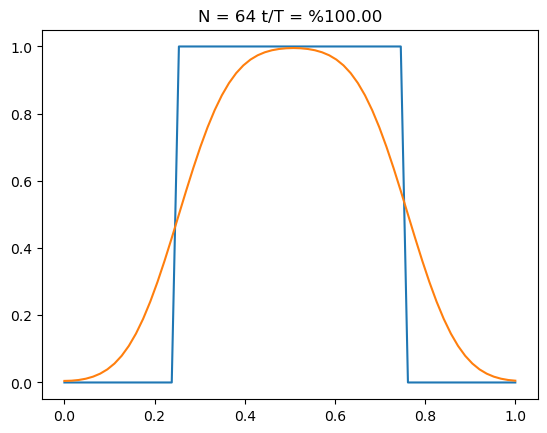

In [3]:
def step_func (Vec_len):
    x = np.linspace(0, 1, Vec_len)  
    y = np.abs(np.where(np.sign(np.cos(2 * np.pi / 1 * x)) > 0, 1, 0)-1) # fliiping sides
    return y

def goust_func(a):
    a_= np.zeros(len(a)+2)
    a_[1:-1] = np.copy(a)
    a_[-1] = a[0]
    a_[0]  = a[-1]
    return a_
    
    
def upwind(a,C,u):
    a = goust_func(a)
    
    if u>0:
        ai = a[1:-1]; aii = a[0:-2]
    
    else:
        ai = a[2:]; aii = a[1:-1]
        
    return ai - C*(ai-aii)




def eps_func(a_end,a0,N):
    dx = 1/N
    return dx * sum((a_end-a0)**2)

def upwind_advection(C=0.5, N=2**6, u=1,plot_init=True,plot_mid=False,plot_end=True):
    dx = 1/N; T = 1/np.abs(u); dt = C/np.abs(u) * dx
    step = []
    step.append(step_func(N))
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    for tt in range(len(t_vec)):
        
        step_t = upwind(step[-1],C,u)
#         step_tx = upwind_x(step_t,dx)
        step.append(step_t)
        
        if tt%50 == 0 and plot_mid == True:   
            plt.plot(x_vec,step[-1]); plt. title (f't/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
    if plot_end == True:
        if plot_init == True:
            plt.plot(x_vec,step[0]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}')
        
        plt.plot(x_vec,step[-1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
        plt.show()

    return step


    print("The time stpes dt the sysem is for CLF is between 0 to 1, so the maximal dt is then dx/u where dx=1/N is the grid step")
if upwind_advection:
    upwind_advection()
        

    

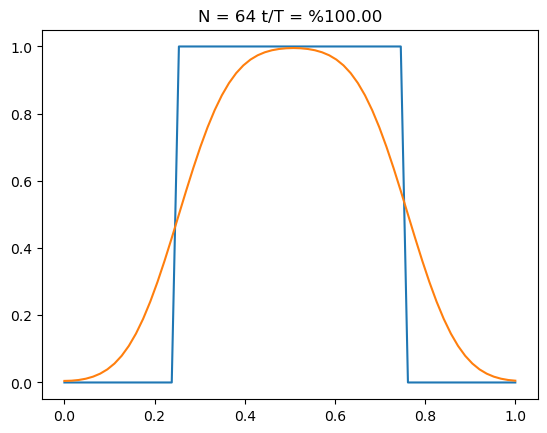

eps = 4.18480e-02


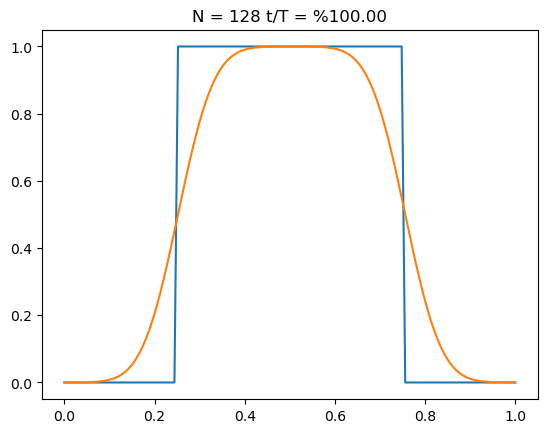

eps = 2.94005e-02


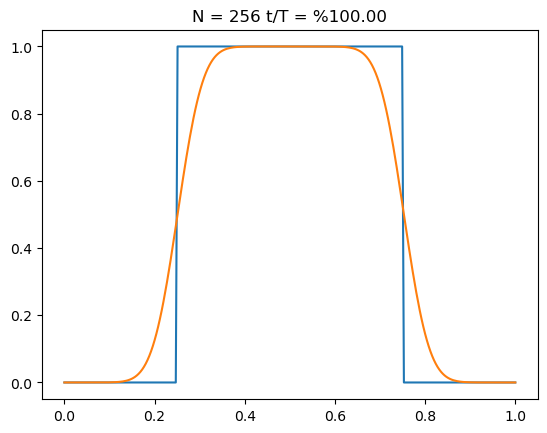

eps = 2.07226e-02


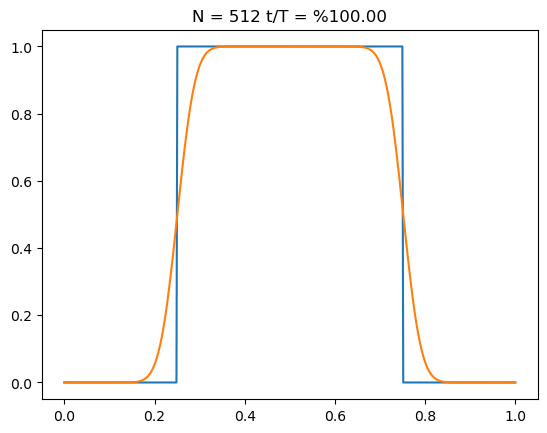

eps = 1.46295e-02


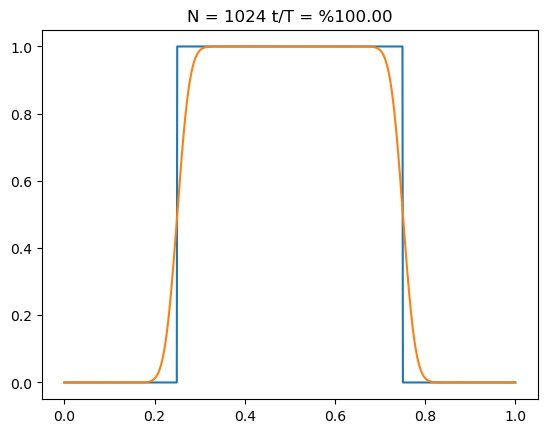

eps = 1.03363e-02


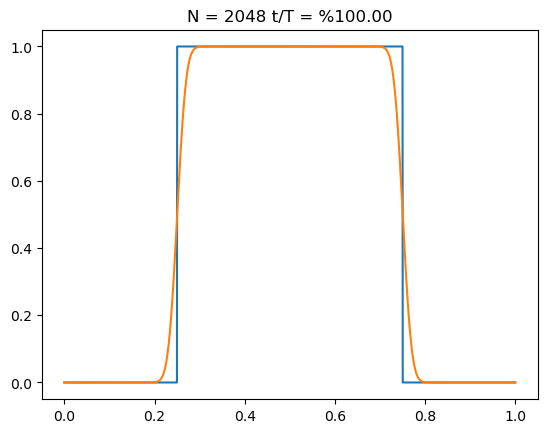

eps = 7.30592e-03


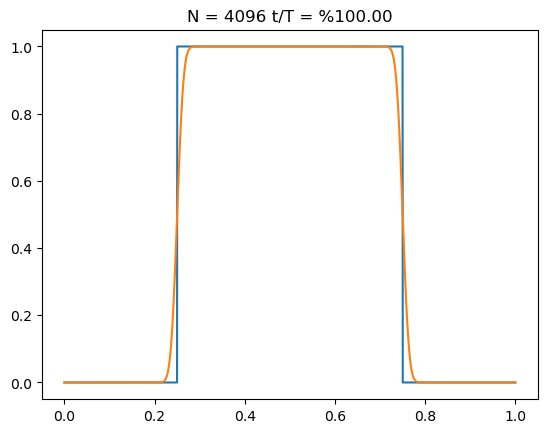

eps = 5.16502e-03


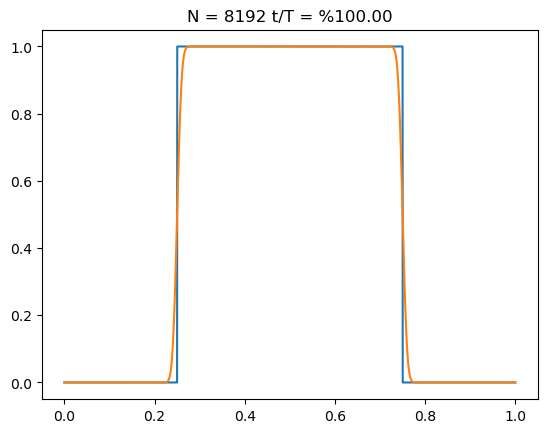

eps = 3.65185e-03


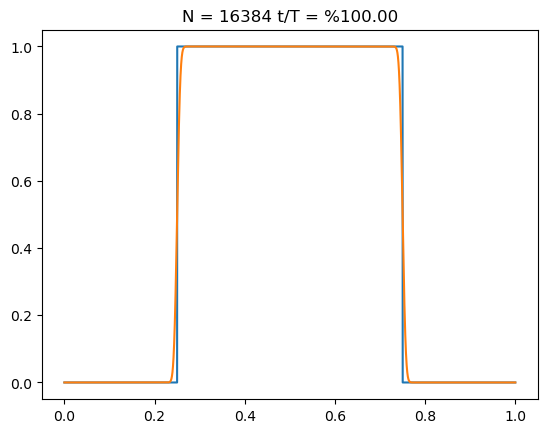

eps = 2.58212e-03


In [4]:
power_vec = np.arange(6,15,1);
N_vec = 2**power_vec
eps = []
for N in N_vec:
    a = upwind_advection(C=0.5 ,N=N , u=1, plot_init=True, plot_mid=False, plot_end=True)
    eps.append(eps_func(a[-1],a[0],N))
    print(f'eps = {eps[-1]:.5e}')
    

##### Linear piecewise reconstruction

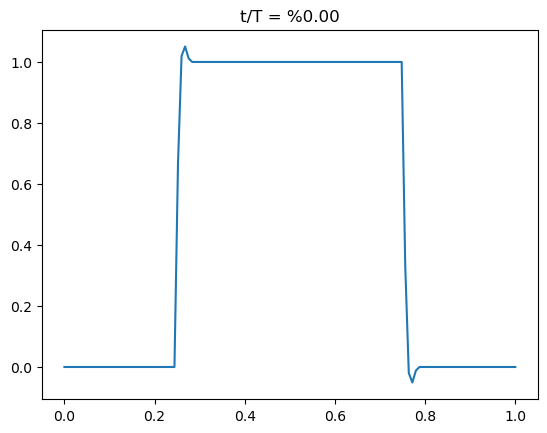

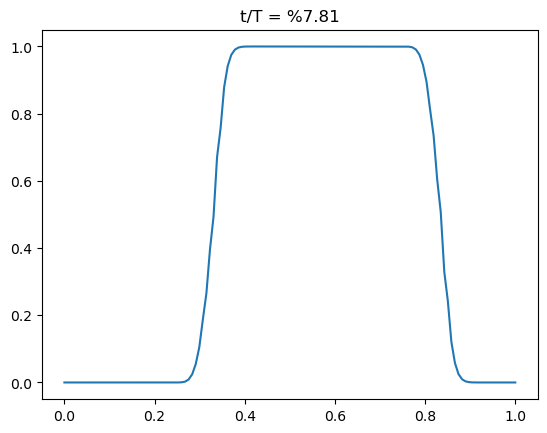

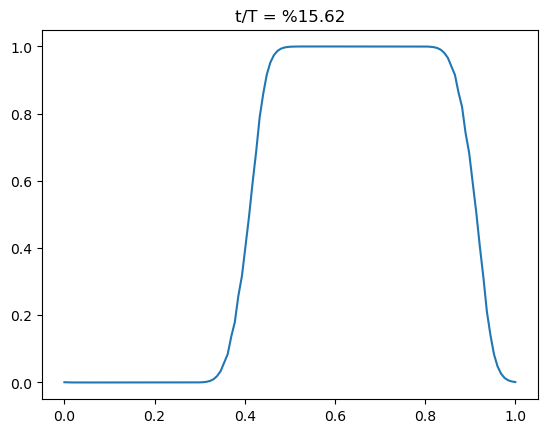

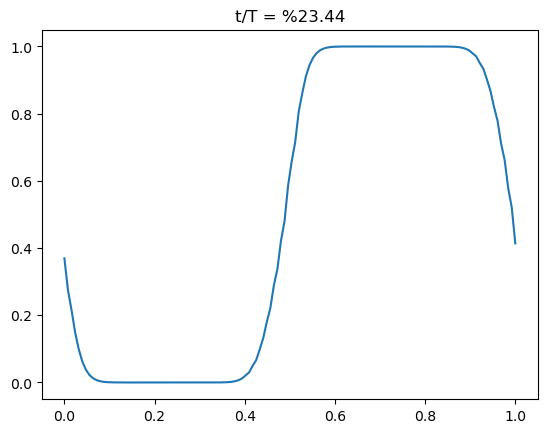

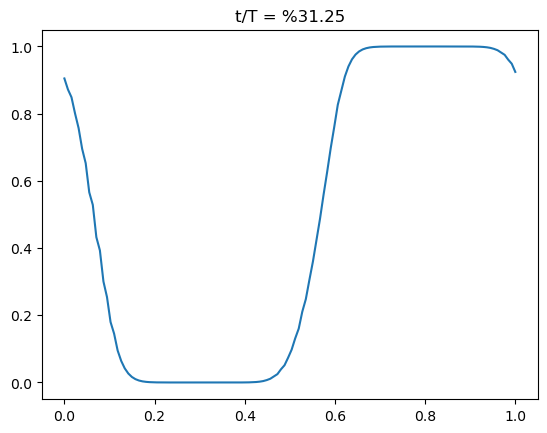

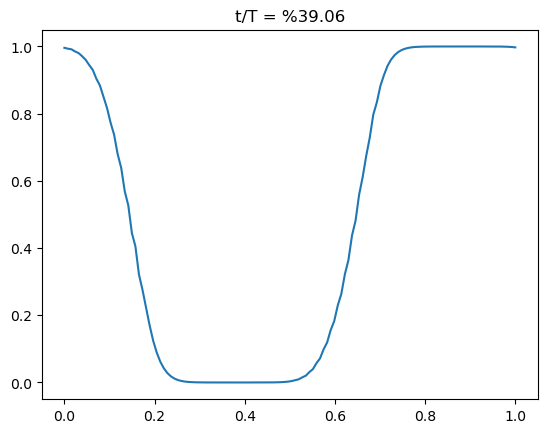

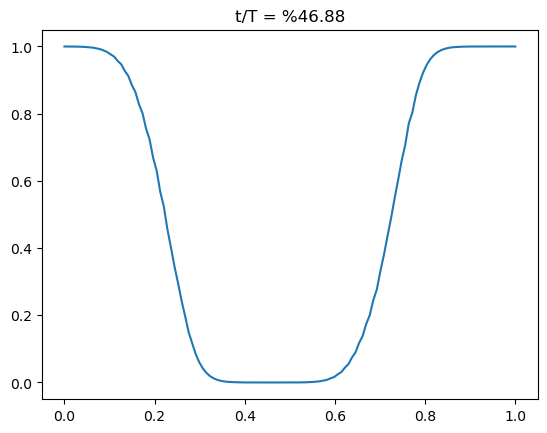

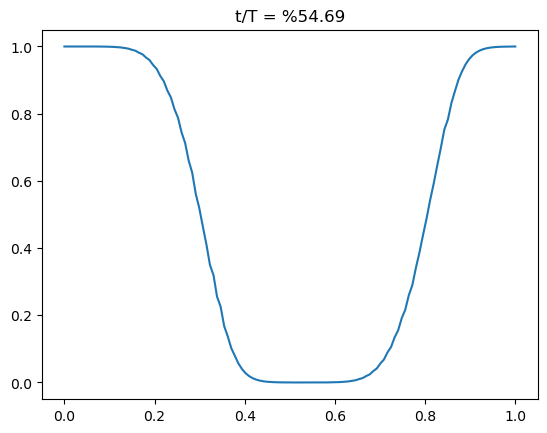

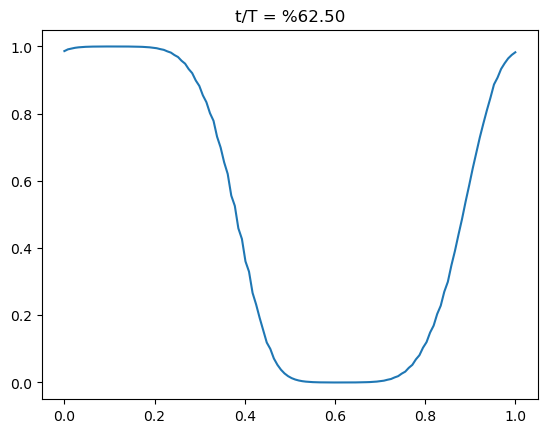

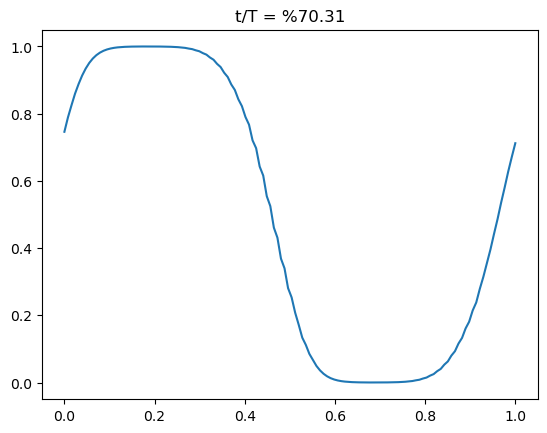

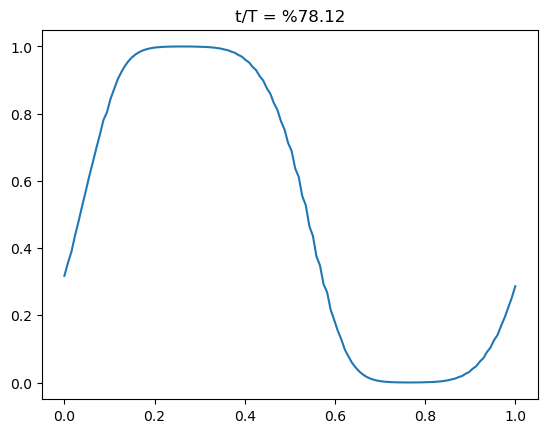

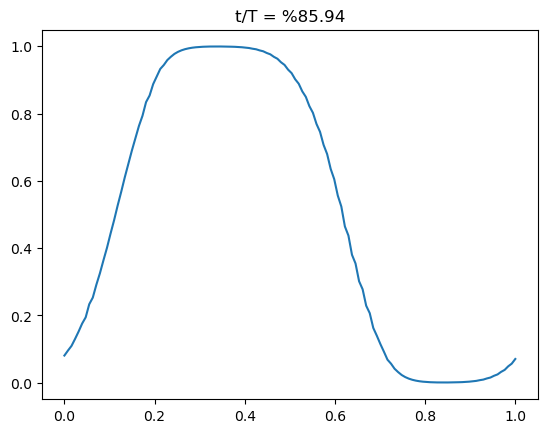

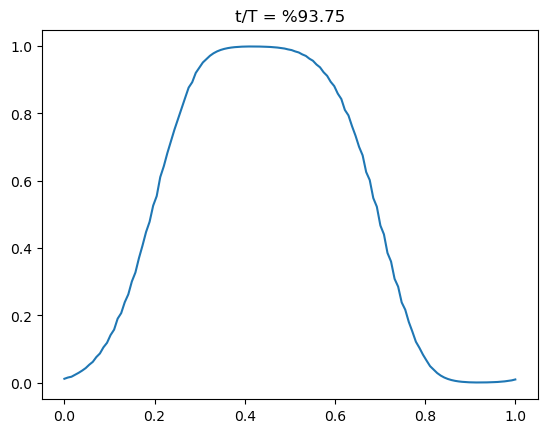

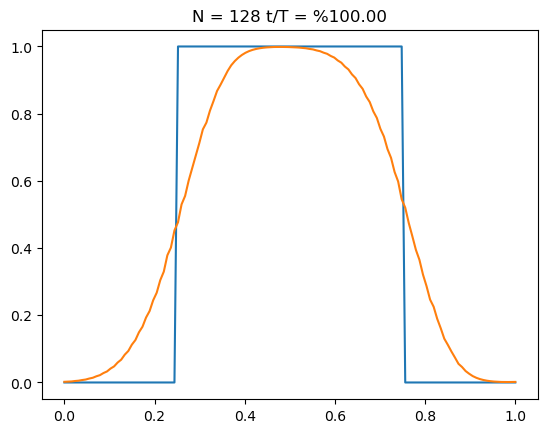

In [192]:
def step_func (Vec_len):
    x = np.linspace(0, 1, Vec_len)  
    y = np.abs(np.where(np.sign(np.cos(2 * np.pi / 1 * x)) > 0, 1, 0)-1) # fliiping sides
    return y

def goust_func(a):
    a_ = np.zeros(len(a)+4)
    a_[2:-2] = np.copy(a)
    a_[-2] = a[0]; #  a_N-1 = a_0
    a_[-1] = a[1] # a_N = a1
    # a_[-1] = a[2]
    a_[0] = a[-2]  # a_-1 = a_N-2
    a_[1] = a[-1]

    return a_

def lax_func (a,C):
    a_ = goust_func(a)
    aip1 = a_[2:-2]; aim1 = a_[0:-4]
    a_new = a + C/2*(aip1-aim1)+ (C**2)/2 * (aip1+aim1-2*a)
    return a_new


def minnod_func(a_):
    Da = np.zeros(len(a_)-2)
    Da_full = np.zeros(len(a_))
    a = a_[1:-1] - a_[:-2]
    b = a_[2:] - a_[1:-1]
#     print(len(Da))
#     print(len(a))
#     print(len(b))
    mask_a = (np.abs(a) < np.abs(b)) & (a * b > 0)       
    idx_a = np.where(mask)[0]
    
    mask_b = (np.abs(a) > np.abs(b)) & (a * b > 0)       
    idx_b= np.where(mask_b)[0]
    
    mask_z = (np.abs(a) == np.abs(b)) | (a * b < 0) 
    idx_z= np.where(mask_z)[0]
              
    Da[idx_a] = a[idx_a]
    Da[idx_b] = b[idx_b]
    Da[idx_z] = 0
    Da_full[1:-1] = Da
    
    return Da_full
    
    
def upwind(a,C,dx,dt,u):
    a_ = goust_func(a)
    N = len(a)
    Da = np.zeros(N+4); a_half_x = np.zeros(N+4); F_1_2 = np.zeros(N+4)      
    a_half_t = np.zeros(N+4) 
    k1 = np.zeros(N+4); k2 = np.zeros(N+4)
    
    
    if u>0:
        Da = minnod_func(a_) /2      
        a_half_x = a_ + Da/2 # upwind from left to right  a
        F_1_2 = u*a_half_x
        k1 = -1/dx * (F_1_2[1:]-F_1_2[:-1])
        a_half_t[1:-1] = a_[1:-1] + dt/2*k1[:-1]
        
        a_half_t[0] = a_half_x[-1]
        Da = minnod_func(a_half_t) /2   
        a_half_x = a_half_t + Da/2 # upwind from left to right  a
           
        F_12_12 = u*(a_half_x[:-1]) 
        k2 = -1/dx * (F_12_12[1:] - F_12_12[:-1])
        a_new = a + dt * k2[1:-1]
    else:
        Da = minnod_func(a_) /2      
        a_half_x = a_ - Da/2 # upwind from left to right  a
        F_1_2 = u*a_half_x
        k1 = -1/dx * (F_1_2[1:]-F_1_2[:-1])
        a_half_t[1:-1] = a_[1:-1] + dt/2*k1[:-1]
        
        a_half_t[-1] = a_half_x[0]
        Da = minnod_func(a_half_t) /2   
        a_half_x = a_half_t - Da/2 # upwind from left to right  a
           
        F_12_12 = u*(a_half_x[1:]) 
        k2 = -1/dx * (F_12_12[1:] - F_12_12[:-1])
        a_new = a + dt * k2[1:-1]
        
        
    return a_new
    

def eps_func(a_end,a0,N):
    dx = 1/N
    return dx * sum((a_end-a0)**2)


def linear_reconstract_func(C=0.5, N=2**7, u=1,plot_init=True,plot_mid=True,plot_end=True):
    dx = 1/N; T = 1/np.abs(u); dt = C/np.abs(u) * dx
    step = []
    stepm2 = np.zeros(N)
    # print(stepm2[0])
    # step.append(stepm2)
    step.append(step_func(N))
    # step.append(step_func(N))
    step.append(lax_func(step[-1],C))
    # print(step[-1])
    t_vec = np.linspace(0,T,round(1/dt)+1)
    x_vec = np.linspace(0,1,N)
    
    for tt in range(len(t_vec)):
        step_ = upwind(step[-1],C,dx,dt,u)
        # step_tx = upwind_x(step_t,dx)
        # print(len(step_tx))
        step.append(step_)
        if tt%20 == 0 and plot_mid == True:   
            plt.plot(x_vec,step[-1]); plt. title (f't/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
    if plot_end == True:
        if plot_init == True:
            plt.plot(x_vec,step[0]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}')
        
        plt.plot(x_vec,step[-1]); plt. title (f'N = {N} t/T = %{t_vec[tt]/T*100:.2f}'); plt.show() 
        plt.show()
    return step
        
if linear_reconstract_func:
    linear_reconstract_func()

In [111]:
[np.array([1,2,3,4])>3]

[array([False, False, False,  True])]

In [132]:
a = np.array([1,2,3,4,5])
b = np.array([2,1,-1,5,4])

# two conditions: a < b  AND  a*b > 0
mask = (a < b) & (a * b > 0)       # elementwise boolean array
idx = np.where(mask)[0]

print(idx)

[0 3]
